# ENTRENAMIENTO HCC-AI

## 1: Anonimización y Preprocesamiento de Imágenes

Dado que las ecografías contienen información sensible, es esencial anonimizar las imágenes antes de procesarlas.


1.   Eliminar datos personales:

        - Eliminar los metadatos sensibles.
        -En imágenes PNG/JPG, eliminar cualquier texto visible sobre datos del paciente.
        -Recortar áreas con información personal.

2.   Organizar carpetas:

        - Hígado Sano: dataset/HigadoSano/
        - Hígado Esteatosis: dataset/HígadoEsteatosis/      
        - Hígado Cirrótico: dataset/HigadoCirrotico/
        - Hepatocarcinoma: dataset/Hepatocarcinoma/
        - Destino Anonimizado: dataset/Anonimizado/HigadoSano/, dataset Anonimizado/HigadoCirrotico/, etc.

3.    Preprocesar imágenes:

        - Convertir a escala de grises.
        - Recortar bordes irrelevantes.
        - Ajustar tamaño a 512x512 píxeles.
        - Guardar imágenes en sus carpetas correspondientes

In [1]:
from google.colab import drive
import cv2
import numpy as np
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import shutil


In [2]:
from google.colab import files
uploaded = files.upload()


Saving HCC_AI_dataset.zip to HCC_AI_dataset.zip


In [3]:
import zipfile

with zipfile.ZipFile("HCC_AI_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content")

print(os.listdir("/content/HCC_AI_dataset"))


['Esteatosis', 'Sano', 'Cirrotico', 'Hepatocarcinoma']


In [4]:
input_folders = {
    "sano":             "/content/HCC_AI_dataset/Sano",
    "esteatosis":       "/content/HCC_AI_dataset/Esteatosis",
    "cirrotico":        "/content/HCC_AI_dataset/Cirrotico",
    "hepatocarcinoma":  "/content/HCC_AI_dataset/Hepatocarcinoma"
}

output_folders = {
    "sano":             "/content/HCC_AI_dataset/Sano/Anonimizadas",
    "esteatosis":       "/content/HCC_AI_dataset/Esteatosis/Anonimizadas",
    "cirrotico":        "/content/HCC_AI_dataset/Cirrotico/Anonimizadas",
    "hepatocarcinoma":  "/content/HCC_AI_dataset/Hepatocarcinoma/Anonimizadas"
}

for folder in output_folders.values():
    os.makedirs(folder, exist_ok=True)


TAMANIO_OBJETIVO = (512, 512)


In [5]:



def pre_recortar_imagen(img, porcentaje=0.15):
    """Recorta un porcentaje de los bordes de la imagen."""
    h, w, _ = img.shape
    delta_h, delta_w = int(h * porcentaje), int(w * porcentaje)
    return img[delta_h:h-delta_h, delta_w:w-delta_w]

def redimensionar_imagen(img, tamano_objetivo):
    """Redimensiona la imagen al tamaño objetivo."""
    return cv2.resize(img, tamano_objetivo)

def procesar_ecografia(image_path, output_path):
    """Proceso de preprocesamiento de imagen."""
    img = cv2.imread(image_path)
    if img is None:
        print(f"[ERROR] No se pudo cargar la imagen: {image_path}")
        return

    img = pre_recortar_imagen(img, 0.15)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.GaussianBlur(img, (5, 5), 0)
    img = redimensionar_imagen(img, TAMANIO_OBJETIVO)

    img = img.astype('float32') / 255.0

    img = np.repeat(img[..., np.newaxis], 3, axis=-1)

    cv2.imwrite(output_path, img * 255)



category_labels = {"sano": 0, "esteatosis": 1, "cirrotico": 2, "hepatocarcinoma": 3}

data = []
errores = []

for category, input_folder in input_folders.items():
    output_folder = output_folders[category]
    filenames = [f for f in os.listdir(input_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    total = len(filenames)

    print(f"\n Procesando categoría: {category} ({total} imágenes)")

    for idx, filename in enumerate(filenames):
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        if not os.path.exists(output_path):
            try:
                procesar_ecografia(input_path, output_path)
            except Exception as e:
                print(f"[ERROR] {filename} no se pudo procesar: {e}")
                errores.append((filename, category, str(e)))
                continue
        else:
            print(f"[INFO] {filename} ya procesado, se omite.")

        data.append((output_path, category))

        if idx % 25 == 0 or idx == total - 1:
            print(f"  ➤ {idx + 1}/{total} imágenes procesadas")

    print(f" Preprocesado completado para {category}. Imágenes guardadas en: {output_folder}")


# Guardar errores si los hay
if errores:
    errores_df = pd.DataFrame(errores, columns=["archivo", "categoria", "error"])
    errores_df.to_csv("errores_procesamiento.csv", index=False)
    print(f"\n❗ Se registraron {len(errores)} errores. Guardados en 'errores_procesamiento.csv'")
else:
    print("\n No se detectaron errores durante el preprocesamiento.")


 Procesando categoría: sano (200 imágenes)
  ➤ 1/200 imágenes procesadas
  ➤ 26/200 imágenes procesadas
  ➤ 51/200 imágenes procesadas
  ➤ 76/200 imágenes procesadas
  ➤ 101/200 imágenes procesadas
  ➤ 126/200 imágenes procesadas
  ➤ 151/200 imágenes procesadas
  ➤ 176/200 imágenes procesadas
  ➤ 200/200 imágenes procesadas
 Preprocesado completado para sano. Imágenes guardadas en: /content/HCC_AI_dataset/Sano/Anonimizadas

 Procesando categoría: esteatosis (200 imágenes)
  ➤ 1/200 imágenes procesadas
  ➤ 26/200 imágenes procesadas
  ➤ 51/200 imágenes procesadas
  ➤ 76/200 imágenes procesadas
  ➤ 101/200 imágenes procesadas
  ➤ 126/200 imágenes procesadas
  ➤ 151/200 imágenes procesadas
  ➤ 176/200 imágenes procesadas
  ➤ 200/200 imágenes procesadas
 Preprocesado completado para esteatosis. Imágenes guardadas en: /content/HCC_AI_dataset/Esteatosis/Anonimizadas

 Procesando categoría: cirrotico (200 imágenes)
  ➤ 1/200 imágenes procesadas
  ➤ 26/200 imágenes procesadas
  ➤ 51/200 imáge


 Resumen del dataset de ecografías:
                 Cantidad  Porcentaje (%)
sano                  200            25.0
esteatosis            200            25.0
cirrotico             200            25.0
hepatocarcinoma       200            25.0


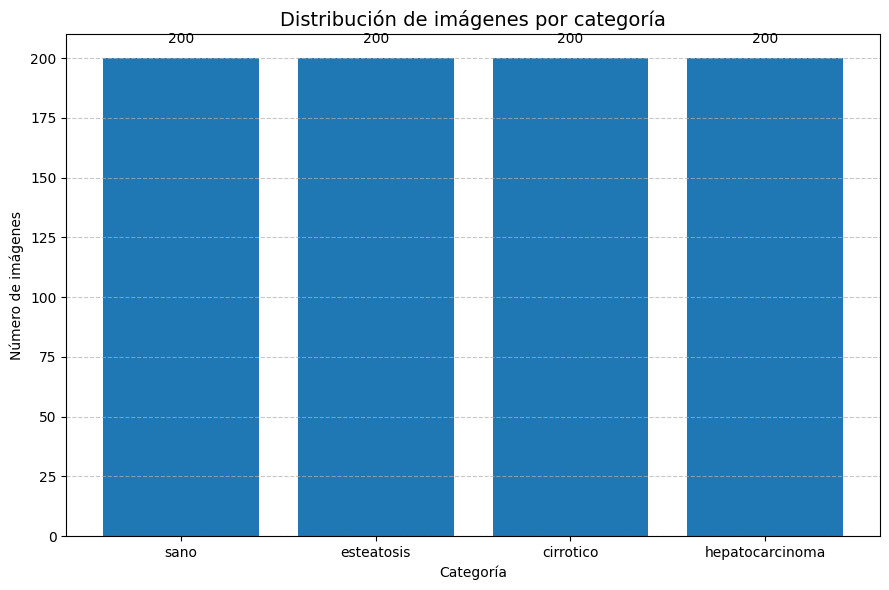

In [6]:
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

conteo_por_categoria = Counter([categoria for _, categoria in data])
total_imagenes = sum(conteo_por_categoria.values())

df_conteo = pd.DataFrame.from_dict(conteo_por_categoria, orient='index', columns=['Cantidad'])
df_conteo['Porcentaje (%)'] = (df_conteo['Cantidad'] / total_imagenes * 100).round(2)
df_conteo = df_conteo.sort_values(by='Cantidad', ascending=False)

print("\n Resumen del dataset de ecografías:")
print(df_conteo)

plt.figure(figsize=(9, 6))
bars = plt.bar(df_conteo.index, df_conteo['Cantidad'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, yval + 5, f'{int(yval)}', ha='center', va='bottom')

plt.title("Distribución de imágenes por categoría", fontsize=14)
plt.xlabel("Categoría")
plt.ylabel("Número de imágenes")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## 2: Creación del Dataset para Entrenamiento
- Etiquetar las imágenes con su categoría (0: Sano, 1: Esteatosis, 2: Cirrótico, 4: Hepatocarcinoma).

- Dividir los datos en conjuntos de entrenamiento (70%), validación (15%) y prueba (15%).

- Guardar en formato estructurado (CSV o carpeta con subdirectorios).

In [7]:
import os
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split

category_labels = {"sano": 0, "esteatosis": 1, "cirrotico": 2, "hepatocarcinoma": 3}
df = pd.DataFrame(data, columns=["path", "label"])
df["class_idx"] = df["label"].map(category_labels)

df_train, df_temp = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=42)
df_val, df_test = train_test_split(df_temp, test_size=0.5, stratify=df_temp["label"], random_state=42)

df_train["set"] = "train"
df_val["set"] = "val"
df_test["set"] = "test"

df_final = pd.concat([df_train, df_val, df_test], ignore_index=True)
df_final.to_csv("/content/HCC_AI_dataset/dataset.csv", index=False)

print("CSV generado con éxito")

data_splits = {"train": df_train, "val": df_val, "test": df_test}

for split, df_split in data_splits.items():
    split_folder = f"/content/HCC_AI_dataset/HCC-AI/{split}"
    os.makedirs(split_folder, exist_ok=True)

    print(f"\n Copiando imágenes al conjunto: {split.upper()} ({len(df_split)} imágenes)")

    for i, row in df_split.iterrows():
        category_folder = os.path.join(split_folder, str(row["class_idx"]))
        os.makedirs(category_folder, exist_ok=True)

        dest_path = os.path.join(category_folder, os.path.basename(row["path"]))

        try:
            shutil.copy(row["path"], dest_path)
            print(f"📄 Copiada: {row['path']} → {dest_path}")
        except Exception as e:
            print(f" Error al copiar {row['path']}: {e}")

print("\n Proceso completado: Etiquetado, división de datos y almacenamiento estructurado.")


CSV generado con éxito

 Copiando imágenes al conjunto: TRAIN (560 imágenes)
📄 Copiada: /content/HCC_AI_dataset/Cirrotico/Anonimizadas/883894-3.jpg → /content/HCC_AI_dataset/HCC-AI/train/2/883894-3.jpg
📄 Copiada: /content/HCC_AI_dataset/Esteatosis/Anonimizadas/2_202502261401326900002.jpg → /content/HCC_AI_dataset/HCC-AI/train/1/2_202502261401326900002.jpg
📄 Copiada: /content/HCC_AI_dataset/Hepatocarcinoma/Anonimizadas/834251-1.jpg → /content/HCC_AI_dataset/HCC-AI/train/3/834251-1.jpg
📄 Copiada: /content/HCC_AI_dataset/Hepatocarcinoma/Anonimizadas/881050-2.jpg → /content/HCC_AI_dataset/HCC-AI/train/3/881050-2.jpg
📄 Copiada: /content/HCC_AI_dataset/Esteatosis/Anonimizadas/3_202502261402138550003.jpg → /content/HCC_AI_dataset/HCC-AI/train/1/3_202502261402138550003.jpg
📄 Copiada: /content/HCC_AI_dataset/Sano/Anonimizadas/413839-2.jpg → /content/HCC_AI_dataset/HCC-AI/train/0/413839-2.jpg
📄 Copiada: /content/HCC_AI_dataset/Sano/Anonimizadas/535126-1.jpg → /content/HCC_AI_dataset/HCC-AI/train

In [8]:
print("\n Distribución de clases por conjunto (train/val/test):\n")

for split_name, df_split in data_splits.items():
    total = len(df_split)
    conteo = df_split["label"].value_counts().sort_index()
    porcentajes = (conteo / total * 100).round(2)

    print(f"- {split_name.upper()} — Total: {total} imágenes")
    for label in conteo.index:
        print(f"   • {label}: {conteo[label]} imágenes ({porcentajes[label]}%)")
    print("-" * 40)



 Distribución de clases por conjunto (train/val/test):

- TRAIN — Total: 560 imágenes
   • cirrotico: 140 imágenes (25.0%)
   • esteatosis: 140 imágenes (25.0%)
   • hepatocarcinoma: 140 imágenes (25.0%)
   • sano: 140 imágenes (25.0%)
----------------------------------------
- VAL — Total: 120 imágenes
   • cirrotico: 30 imágenes (25.0%)
   • esteatosis: 30 imágenes (25.0%)
   • hepatocarcinoma: 30 imágenes (25.0%)
   • sano: 30 imágenes (25.0%)
----------------------------------------
- TEST — Total: 120 imágenes
   • cirrotico: 30 imágenes (25.0%)
   • esteatosis: 30 imágenes (25.0%)
   • hepatocarcinoma: 30 imágenes (25.0%)
   • sano: 30 imágenes (25.0%)
----------------------------------------


In [9]:
import os

label_map = {
    "0": "sano",
    "1": "esteatosis",
    "2": "cirrotico",
    "3": "hepatocarcinoma"
}

base_dir = "/content/HCC_AI_dataset/HCC-AI"


for split in ["train", "val", "test"]:
    split_path = os.path.join(base_dir, split)
    for old_name, new_name in label_map.items():
        old_path = os.path.join(split_path, old_name)
        new_path = os.path.join(split_path, new_name)
        if os.path.exists(old_path):
            os.rename(old_path, new_path)
            print(f" Renombrado: {old_path} → {new_path}")


 Renombrado: /content/HCC_AI_dataset/HCC-AI/train/0 → /content/HCC_AI_dataset/HCC-AI/train/sano
 Renombrado: /content/HCC_AI_dataset/HCC-AI/train/1 → /content/HCC_AI_dataset/HCC-AI/train/esteatosis
 Renombrado: /content/HCC_AI_dataset/HCC-AI/train/2 → /content/HCC_AI_dataset/HCC-AI/train/cirrotico
 Renombrado: /content/HCC_AI_dataset/HCC-AI/train/3 → /content/HCC_AI_dataset/HCC-AI/train/hepatocarcinoma
 Renombrado: /content/HCC_AI_dataset/HCC-AI/val/0 → /content/HCC_AI_dataset/HCC-AI/val/sano
 Renombrado: /content/HCC_AI_dataset/HCC-AI/val/1 → /content/HCC_AI_dataset/HCC-AI/val/esteatosis
 Renombrado: /content/HCC_AI_dataset/HCC-AI/val/2 → /content/HCC_AI_dataset/HCC-AI/val/cirrotico
 Renombrado: /content/HCC_AI_dataset/HCC-AI/val/3 → /content/HCC_AI_dataset/HCC-AI/val/hepatocarcinoma
 Renombrado: /content/HCC_AI_dataset/HCC-AI/test/0 → /content/HCC_AI_dataset/HCC-AI/test/sano
 Renombrado: /content/HCC_AI_dataset/HCC-AI/test/1 → /content/HCC_AI_dataset/HCC-AI/test/esteatosis
 Renombrad


 TRAIN set:
   • sano: 140 imágenes (25.00%)
   • esteatosis: 140 imágenes (25.00%)
   • cirrotico: 140 imágenes (25.00%)
   • hepatocarcinoma: 140 imágenes (25.00%)


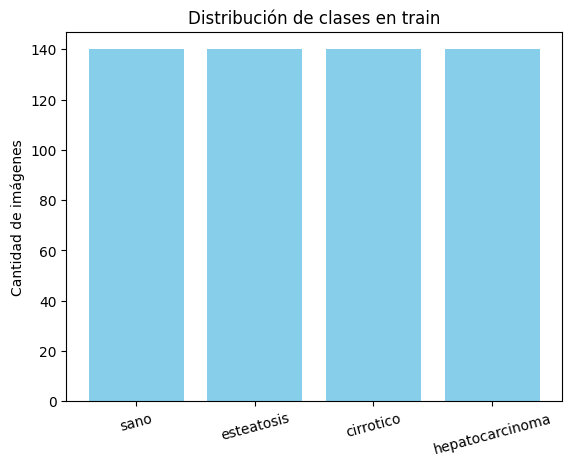


 VAL set:
   • sano: 30 imágenes (25.00%)
   • esteatosis: 30 imágenes (25.00%)
   • cirrotico: 30 imágenes (25.00%)
   • hepatocarcinoma: 30 imágenes (25.00%)


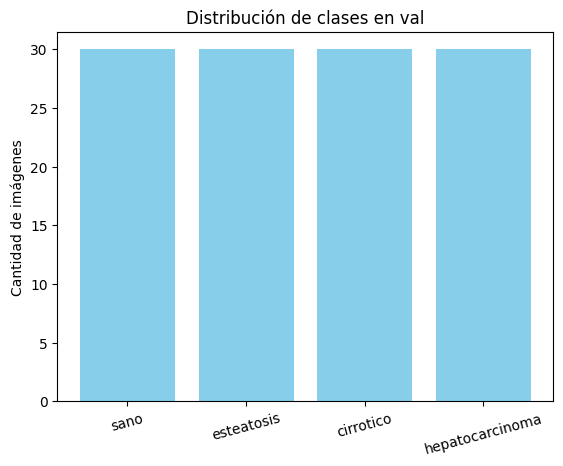


 TEST set:
   • sano: 30 imágenes (25.00%)
   • esteatosis: 30 imágenes (25.00%)
   • cirrotico: 30 imágenes (25.00%)
   • hepatocarcinoma: 30 imágenes (25.00%)


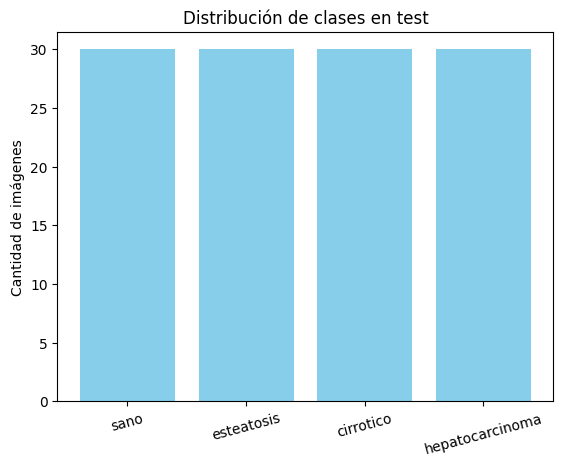

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

base_dir = "/content/HCC_AI_dataset/HCC-AI"
subsets = ['train', 'val', 'test']
class_names = ['sano', 'esteatosis', 'cirrotico', 'hepatocarcinoma']

for subset in subsets:
    print(f"\n {subset.upper()} set:")
    subset_path = os.path.join(base_dir, subset)
    class_counts = {}
    total = 0
    for class_name in class_names:
        class_dir = os.path.join(subset_path, class_name)
        count = len(os.listdir(class_dir))
        class_counts[class_name] = count
        total += count
    for cls, cnt in class_counts.items():
        print(f"   • {cls}: {cnt} imágenes ({cnt/total*100:.2f}%)")

    plt.figure()
    plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
    plt.title(f"Distribución de clases en {subset}")
    plt.ylabel("Cantidad de imágenes")
    plt.xticks(rotation=15)
    plt.show()


In [11]:
import os

base_dir = "/content/HCC_AI_dataset/HCC-AI"

print(f"\n Explorando estructura de: {base_dir}\n")

for split in sorted(os.listdir(base_dir)):
    split_path = os.path.join(base_dir, split)
    if not os.path.isdir(split_path):
        continue

    print(f" {split}/")

    for class_name in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, class_name)
        if not os.path.isdir(class_path):
            continue

        images = sorted(os.listdir(class_path))
        print(f"   ├──  {class_name}/ ({len(images)} imágenes)")

        # Mostrar hasta 3 nombres de archivo como muestra
        for img_name in images[:3]:
            print(f"   │       {img_name}")

        if len(images) > 3:
            print(f"   │      ... ({len(images) - 3} más)")



 Explorando estructura de: /content/HCC_AI_dataset/HCC-AI

 test/
   ├──  cirrotico/ (30 imágenes)
   │       227224-1.jpg
   │       227224-2.jpg
   │       281170-1.jpg
   │      ... (27 más)
   ├──  esteatosis/ (30 imágenes)
   │       1_202502261401336040001.jpg
   │       1_202502261401345200001.jpg
   │       1_202502261401432160001.jpg
   │      ... (27 más)
   ├──  hepatocarcinoma/ (30 imágenes)
   │       238051-1.jpg
   │       238051-2.jpg
   │       475596-1.jpg
   │      ... (27 más)
   ├──  sano/ (30 imágenes)
   │       206267-2.jpg
   │       206471-1.jpg
   │       249118-1.jpg
   │      ... (27 más)
 train/
   ├──  cirrotico/ (140 imágenes)
   │       204195-2.jpg
   │       215760-1.jpg
   │       215760-2.jpg
   │      ... (137 más)
   ├──  esteatosis/ (140 imágenes)
   │       1_202502261402009170001.jpg
   │       1_202502261402138550001.jpg
   │       1_202502261402177520001.jpg
   │      ... (137 más)
   ├──  hepatocarcinoma/ (140 imágenes)
   │       220810-1.

## Una vez tenemos los datos preparados entrenamos el modelo

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import os
import numpy as np

# ==================== Configuración
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4
class_names = ['sano', 'esteatosis', 'cirrotico', 'hepatocarcinoma']
base_dir = "/content/HCC_AI_dataset/HCC-AI"

# ==================== Generadores
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.25,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(base_dir, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)
print("Clases detectadas:", train_generator.class_indices)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2, 3]),
    y=train_generator.classes
)

class_weights_dict = dict(enumerate(class_weights))
print("Pesos por clase:", class_weights_dict)

# ==================== CNN

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])





model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==================== Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# ==================== Entrenamiento
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=40,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr]
)


Found 560 images belonging to 4 classes.
Found 120 images belonging to 4 classes.
Found 120 images belonging to 4 classes.
Clases detectadas: {'cirrotico': 0, 'esteatosis': 1, 'hepatocarcinoma': 2, 'sano': 3}
Pesos por clase: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,948 (49.36 MB)

 Trainable params: 12,938,948 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - accuracy: 0.3005 - loss: 1.3781

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


18/18 ━━━━━━━━━━━━━━━━━━━━ 24s 931ms/step - accuracy: 0.2995 - loss: 1.3780 - val_accuracy: 0.3417 - val_loss: 1.3464 - learning_rate: 1.0000e-04
Epoch 2/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 422ms/step - accuracy: 0.3455 - loss: 1.3399 - val_accuracy: 0.3750 - val_loss: 1.2844 - learning_rate: 1.0000e-04
Epoch 3/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 482ms/step - accuracy: 0.3603 - loss: 1.2837 - val_accuracy: 0.4500 - val_loss: 1.1818 - learning_rate: 1.0000e-04
Epoch 4/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 489ms/step - accuracy: 0.4286 - loss: 1.2294 - val_accuracy: 0.3833 - val_loss: 1.1875 - learning_rate: 1.0000e-04
Epoch 5/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 484ms/step - accuracy: 0.3972 - loss: 1.1737 - val_accuracy: 0.4750 - val_loss: 1.1066 - learning_rate: 1.0000e-04
Epoch 6/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 417ms/step - accuracy: 0.4070 - loss: 1.1557 - val_accuracy: 0.4333 - val_loss: 1.1611 - learning_rate: 1.0000e-04
Epoch 7/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 482ms/step - accuracy: 0.4775 - 

In [13]:
loss, acc = model.evaluate(test_generator)
print(f" Test Accuracy: {acc:.2%}")


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6458 - loss: 0.9197
 Test Accuracy: 58.33%


In [14]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = np.argmax(model.predict(test_generator), axis=1)
y_true = test_generator.classes

print(classification_report(y_true, y_pred, target_names=class_names))


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step
                 precision    recall  f1-score   support

           sano       0.51      0.77      0.61        30
     esteatosis       0.70      0.77      0.73        30
      cirrotico       0.56      0.17      0.26        30
hepatocarcinoma       0.58      0.63      0.60        30

       accuracy                           0.58       120
      macro avg       0.58      0.58      0.55       120
   weighted avg       0.58      0.58      0.55       120



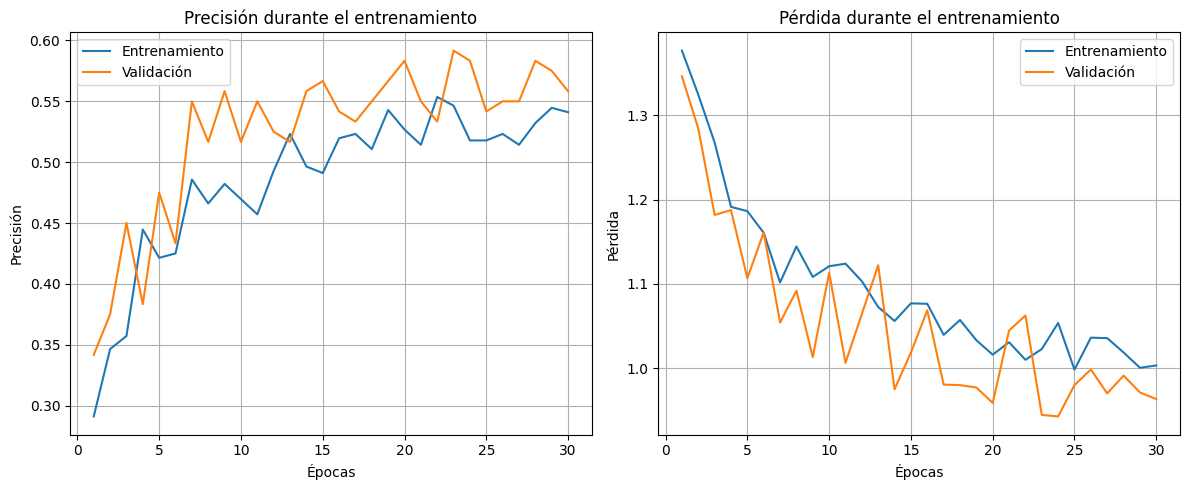

In [16]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# === Gráfica de Precisión ===
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entrenamiento')
plt.plot(epochs_range, val_acc, label='Validación')
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

# === Gráfica de Pérdida ===
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entrenamiento')
plt.plot(epochs_range, val_loss, label='Validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step


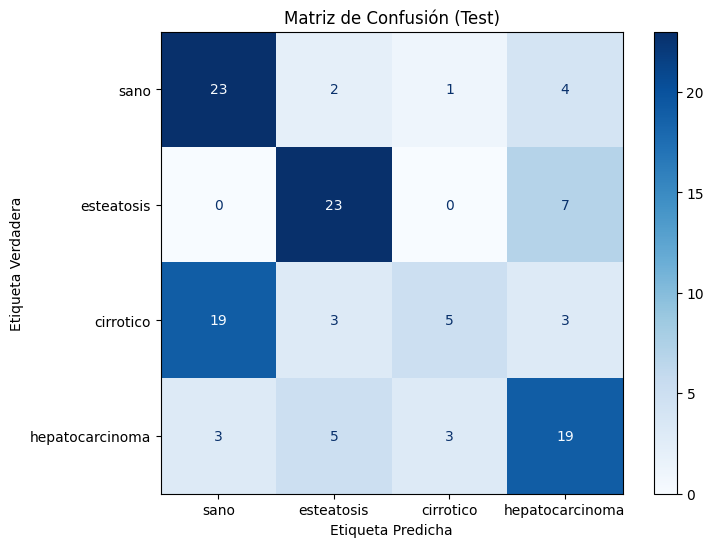

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Obtener predicciones
y_pred = np.argmax(model.predict(test_generator), axis=1)
y_true = test_generator.classes

# Generar matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Mostrar matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Matriz de Confusión (Test)")
plt.xlabel("Etiqueta Predicha")
plt.ylabel("Etiqueta Verdadera")
plt.grid(False)
plt.show()


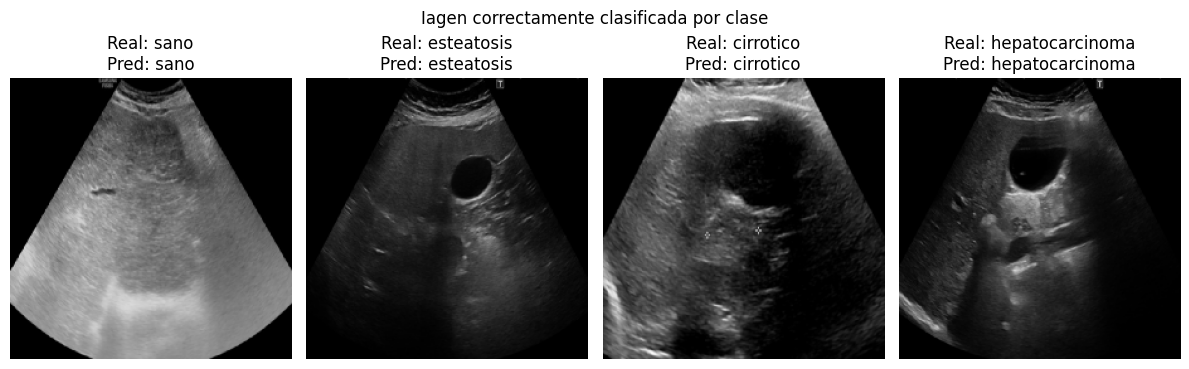

In [27]:
import matplotlib.pyplot as plt
import numpy as np

test_generator.reset()

y_prob = model.predict(test_generator, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_generator.classes
X_test = np.concatenate([test_generator[i][0] for i in range(len(test_generator))])

n = 2
correct_images_nth = {}
class_counts = {i: 0 for i in range(len(class_names))}

for idx in range(len(y_true)):
    true_label = y_true[idx]
    pred_label = y_pred[idx]
    if true_label == pred_label:
        class_counts[true_label] += 1
        if class_counts[true_label] == n:
            correct_images_nth[true_label] = idx
    if len(correct_images_nth) == len(class_names):
        break

plt.figure(figsize=(12, 4))
for i, (label, idx) in enumerate(correct_images_nth.items()):
    img = X_test[idx]
    true_class = class_names[y_true[idx]]
    pred_class = class_names[y_pred[idx]]
    plt.subplot(1, len(class_names), i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Real: {true_class}\nPred: {pred_class}")
plt.suptitle(f"Iagen correctamente clasificada por clase")
plt.tight_layout()
plt.show()


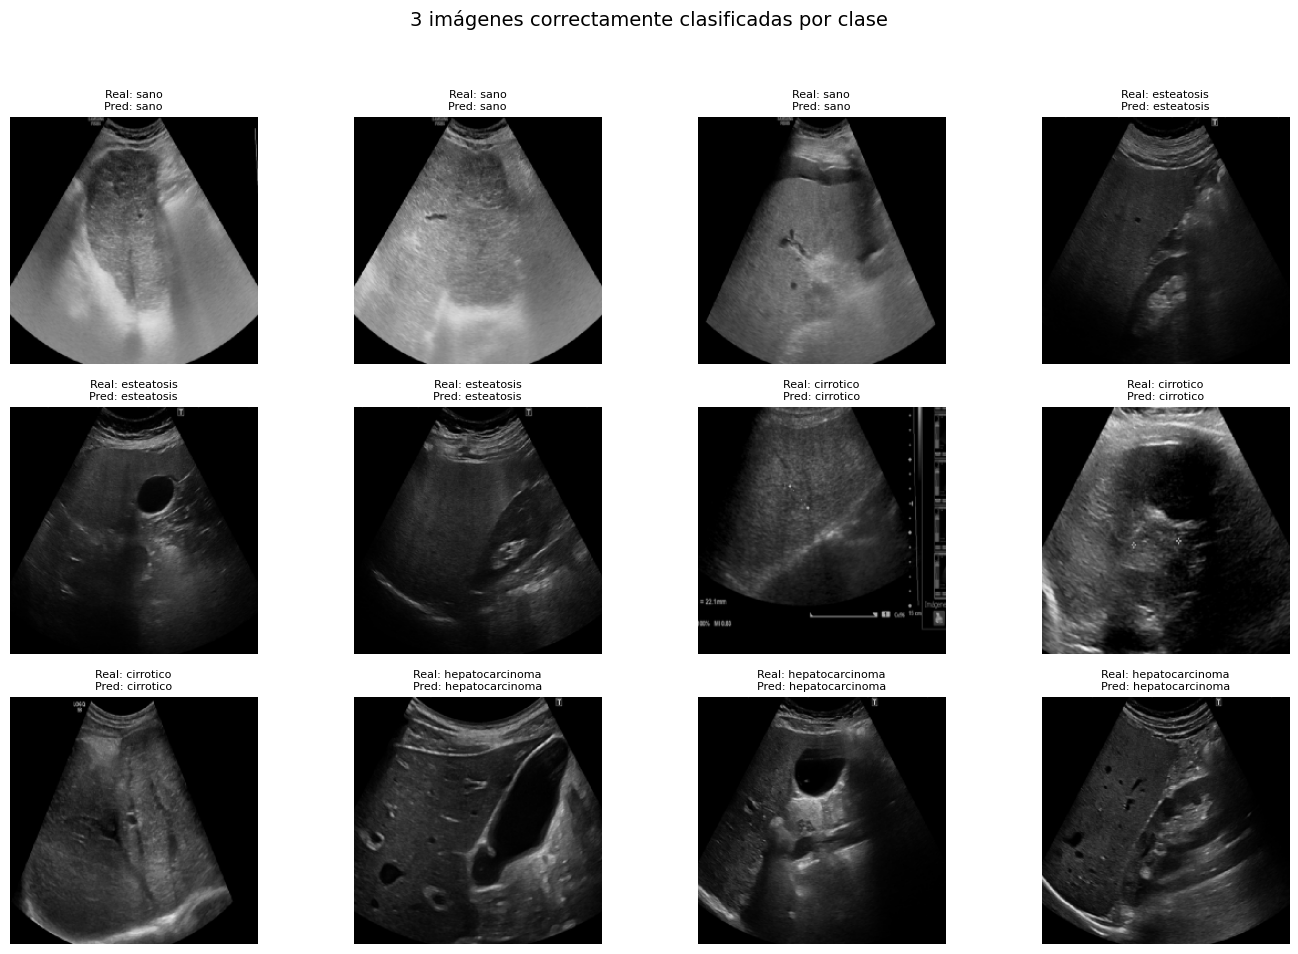

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


test_generator.reset()


y_prob = model.predict(test_generator, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_generator.classes
X_test = np.concatenate([test_generator[i][0] for i in range(len(test_generator))])


N = 3
correct_images_per_class = {i: [] for i in range(len(class_names))}


for idx in range(len(y_true)):
    true_label = y_true[idx]
    pred_label = y_pred[idx]
    if true_label == pred_label and len(correct_images_per_class[true_label]) < N:
        correct_images_per_class[true_label].append(idx)
    if all(len(v) == N for v in correct_images_per_class.values()):
        break


plt.figure(figsize=(14, 10))
for row, class_id in enumerate(correct_images_per_class):
    for col, idx in enumerate(correct_images_per_class[class_id]):
        img = X_test[idx]
        true_class = class_names[y_true[idx]]
        pred_class = class_names[y_pred[idx]]
        plot_idx = row * N + col + 1
        plt.subplot(N, len(class_names), plot_idx)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Real: {true_class}\nPred: {pred_class}", fontsize=8)

plt.suptitle("3 imágenes correctamente clasificadas por clase", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [15]:
model.save("modelo_hcc_ai_cnn.h5")
